In [73]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report

In [74]:
iris=load_iris()
x=iris.data
y=iris.target
print("Feature names:")
print(iris.feature_names)
print("\nTarget names:")
print(iris.target_names)
print("\n Shape of dataset:",x.shape)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

 Shape of dataset: (150, 4)


In [75]:
#convert to binary classification
y_binary=(y!=0).astype(int)
print("Binary labels:")
print(np.unique(y_binary,return_counts=True))

Binary labels:
(array([0, 1]), array([ 50, 100]))


In [76]:
x_two=x[:,[2,3]]
x_train,x_test,y_train,y_test=train_test_split(
    x_two,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [77]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
svm = svm.SVC(kernel='linear')


In [78]:
#Train the linear svm
linear_svm = SVC(kernel='linear', C=1.0)
linear_svm.fit(x_train_scaled,y_train)
y_pred=linear_svm.predict(x_test_scaled)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("\n Classification Report:")
print(classification_report(y_test,y_pred))

Accuracy: 1.0

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



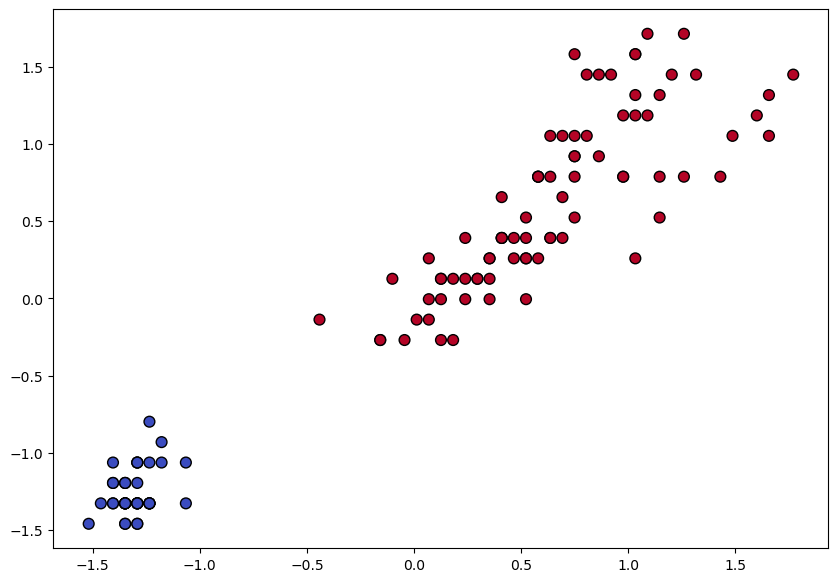

In [79]:
plt.figure(figsize=(10,7))
plt.scatter(
    x_train_scaled[:,0],
    x_train_scaled[:,1],
    c=y_train,
    s=60,
    cmap='coolwarm',
    edgecolors='k'
)


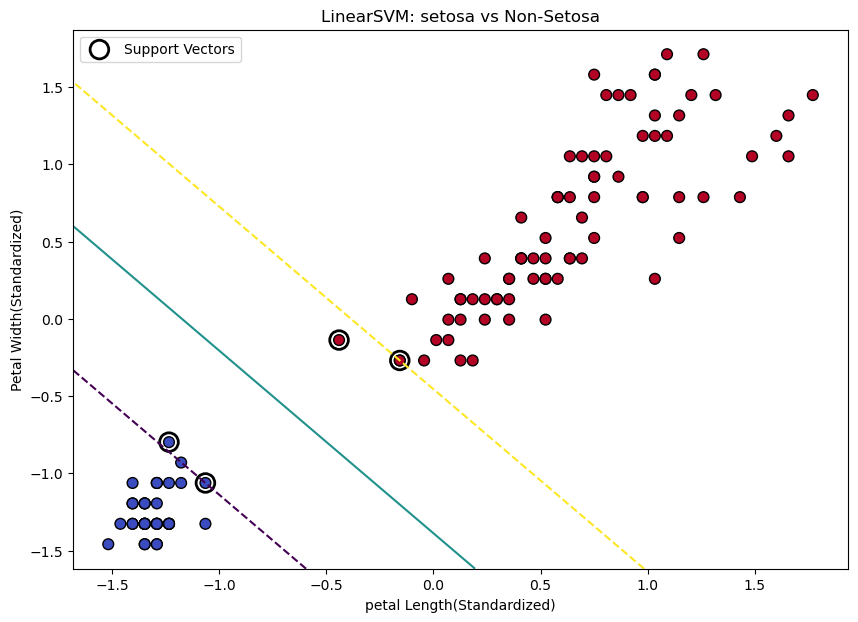

In [80]:
plt.figure(figsize=(10,7))
plt.scatter(
    x_train_scaled[:,0],
    x_train_scaled[:,1],
    c=y_train,
    s=60,
    cmap='coolwarm',
    edgecolors='k'
)
ax=plt.gca()
xlim=ax.get_xlim()
ylim=ax.get_ylim()
xx=np.linspace(xlim[0],xlim[1],200)
yy=np.linspace(ylim[0],ylim[1],200)
YY,XX =np.meshgrid(yy,xx)
xy= np.vstack([XX.ravel(),YY.ravel()]).T
Z=linear_svm.decision_function(xy)
Z=Z.reshape(XX.shape)
ax.contour(
    XX,
    YY,
    Z,
    levels=[-1,0,1],
    linestyles=['--','-','--']
)
ax.scatter(
    linear_svm.support_vectors_[:,0],
    linear_svm.support_vectors_[:,1],
    s=180,
    facecolors='none',
    edgecolor='black',
    linewidths=2,
    label='Support Vectors'
)
plt.xlabel("petal Length(Standardized)")
plt.ylabel("Petal Width(Standardized)")
plt.title("LinearSVM: setosa vs Non-Setosa")
plt.legend()
plt.show()



In [84]:
x_full = iris.data
y_full = iris.target

# Split the dataset
x_train_full, x_test_full, y_train_full, y_test_full = train_test_split(
    x_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

# Standardize the features
scaler_full = StandardScaler()
x_train_full = scaler_full.fit_transform(x_train_full)
x_test_full = scaler_full.transform(x_test_full)

# Define SVM models
models = {
    "Linear": SVC(kernel="linear", C=1.0),
    "Polynomial": SVC(kernel="poly", degree=3, C=1.0),
    "RBF": SVC(kernel="rbf", C=1.0, gamma="scale")
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    model.fit(x_train_full, y_train_full)

    y_pred = model.predict(x_test_full)
    accuracy = accuracy_score(y_test_full, y_pred)
    results[name] = accuracy

    print(f"\n{name} Kernel")
    print("-" * 30)
    print("Accuracy:", accuracy)
    print(
        classification_report(
            y_test_full,
            y_pred,
            target_names=iris.target_names
        )
    )



Linear Kernel
------------------------------
Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Polynomial Kernel
------------------------------
Accuracy: 0.9
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.70      0.82        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30


RBF Kernel
------------------------------
Accuracy: 0.9666666666666667
              precision    recall  f1-scor